In [ ]:
%load_ext autoreload
%autoreload 2
import os
import json
from persona_based_prediction_llm_runner import PersonaBasedPredictionLLMRunner
import pandas as pd


In [ ]:
country_a = "UKR"
country_b = "TUR"
wave_a = 6
wave_b = 7
wave_c = 5

In [ ]:
# get all questions where there was a signidicant change between wave_a and wave_b for country_a and then also for country_b
question_prefixes_to_skip = ['E179']


significant_changes_path = '/home/tchakrab/gb-scratch/wvs/data/significant_changes'
prefixes = ['A']
country_a_sig_changes = []
country_b_sig_changes = []
for question_prefix in prefixes:
    sig_changes = pd.read_csv(f'{significant_changes_path}/ks/{question_prefix}_wave{wave_a}_to_wave{wave_b}.csv')
    # remove from this any rows where the "question" starts with any of the question_prefixes_to_skip
    sig_changes = sig_changes[~sig_changes['question'].str.startswith(tuple(question_prefixes_to_skip))]
    # countryA
    sig_changes_a = sig_changes[sig_changes['country'] == country_a]
    sig_changes_b = sig_changes[sig_changes['country'] == country_b]
    country_a_sig_changes.extend(sig_changes_a['question'].tolist())
    country_b_sig_changes.extend(sig_changes_b['question'].tolist())


#  get all questions where there was a signidicant change between wave_c and wave_a for country_a and b
country_a_sig_changes_2 = []
country_b_sig_changes_2 = []
for question_prefix in prefixes:
    sig_changes = pd.read_csv(f'{significant_changes_path}/ks/{question_prefix}_wave{wave_c}_to_wave{wave_a}.csv')
    # remove from this any rows where the "question" starts with any of the question_prefixes_to_skip
    sig_changes = sig_changes[~sig_changes['question'].str.startswith(tuple(question_prefixes_to_skip))]
    # countryA
    sig_changes_a = sig_changes[sig_changes['country'] == country_a]
    sig_changes_b = sig_changes[sig_changes['country'] == country_b]
    country_a_sig_changes_2.extend(sig_changes_a['question'].tolist())
    country_b_sig_changes_2.extend(sig_changes_b['question'].tolist())

In [ ]:
# print number of sig changes for each country
print(f'Number of significant changes for {country_a}: {len(country_a_sig_changes)}')
print(f'Number of significant changes for {country_b}: {len(country_b_sig_changes)}')
# print how many are common
common_sig_changes = set(country_a_sig_changes).intersection(set(country_b_sig_changes))
print(f'Number of common significant changes: {len(common_sig_changes)}')


# print the second set
print(f'Number of significant changes between wave {wave_c} and wave {wave_a} for {country_a}: {len(country_a_sig_changes_2)}')
print(f'Number of significant changes between wave {wave_c} and wave {wave_a} for {country_b}: {len(country_b_sig_changes_2)}')
common_sig_changes_2 = set(country_a_sig_changes_2).intersection(set(country_b_sig_changes_2))
print(f'Number of common significant changes between wave {wave_c} and wave {wave_a}: {len(common_sig_changes_2)}')

#  common questions for country a for the two sets
common_a = set(country_a_sig_changes).intersection(set(country_a_sig_changes_2))
print(f'Number of common significant changes for {country_a} between the two sets: {len(common_a)}')

In [ ]:
# initialize the runner for country_a and wave_a, and so on
runner = PersonaBasedPredictionLLMRunner()

In [ ]:
raw_results_aa, parsed_results_aa = runner.run_full_pipeline(country_a, wave_a, target_questions=country_a_sig_changes)
# raw_results_bb, parsed_results_bb = runner.run_full_pipeline(country_b, wave_b, target_questions=country_b_sig_changes) 
# raw_results_ba, parsed_results_ba = runner.run_full_pipeline(country_b, wave_a, target_questions=country_b_sig_changes)

In [ ]:
raw_results_ab, parsed_results_ab = runner.run_full_pipeline(country_a, wave_b, target_questions=country_a_sig_changes)


In [ ]:
raw_results_ac, parsed_results_ac = runner.run_full_pipeline(country_a, wave_c, target_questions=country_a_sig_changes_2)

In [ ]:
raw_results_aa_2, parsed_results_aa_2 = runner.run_full_pipeline(country_a, wave_a, target_questions=country_a_sig_changes_2)

In [67]:
#  read the results for country_a for wave_a and wave_b
wave_5_to_6_5 = '/home/tchakrab/gb-scratch/wvs/results/results_new/persona_based_prediction_parsed_UKR_5.json'
wave_5_to_6_6 = '/home/tchakrab/gb-scratch/wvs/results/results_new/persona_based_prediction_parsed_UKR_6.json'
wave_6_to_7_6 = '/home/tchakrab/gb-scratch/wvs/results/results_new/persona_based_prediction_parsed_UKR_6_.json'
wave_6_to_7_7 = '/home/tchakrab/gb-scratch/wvs/results/results_new/persona_based_prediction_parsed_UKR_7.json'

with open(wave_5_to_6_5, 'r') as f:
    results_5_to_6_5 = json.load(f)
    # convert to df
    results_5_to_6_5_df = pd.DataFrame.from_dict(results_5_to_6_5, orient='index')
    results_5_to_6_5_df = results_5_to_6_5_df.map(lambda x: x.get('llm_response') if isinstance(x, dict) else x)
with open(wave_5_to_6_6, 'r') as f:
    results_5_to_6_6 = json.load(f)
    results_5_to_6_6_df = pd.DataFrame.from_dict(results_5_to_6_6, orient='index')
    results_5_to_6_6_df = results_5_to_6_6_df.map(lambda x: x.get('llm_response') if isinstance(x, dict) else x)
with open(wave_6_to_7_6, 'r') as f:
    results_6_to_7_6 = json.load(f)
    results_6_to_7_6_df = pd.DataFrame.from_dict(results_6_to_7_6, orient='index')
    results_6_to_7_6_df = results_6_to_7_6_df.map(lambda x: x.get('llm_response') if isinstance(x, dict) else x)
with open(wave_6_to_7_7, 'r') as f:
    results_6_to_7_7 = json.load(f)
    results_6_to_7_7_df = pd.DataFrame.from_dict(results_6_to_7_7, orient='index')
    results_6_to_7_7_df = results_6_to_7_7_df.map(lambda x: x.get('llm_response') if isinstance(x, dict) else x)

In [73]:
# now for results_5_to_6_5_df compute the average value for each question, which is various columns
# skip columns where it is not a number
import numpy as np
# for each column, compute the average across all rows for all the dfs, and store in separate dicts
dfs = {'results_5_to_6_5_df': results_5_to_6_5_df,
       'results_5_to_6_6_df': results_5_to_6_6_df,
       'results_6_to_7_6_df': results_6_to_7_6_df,
       'results_6_to_7_7_df': results_6_to_7_7_df}
average_results = {}
for df_name, df in dfs.items():
    average_results[df_name] = {}
    for column in df.columns:
        # check if the column is numeric
        if pd.api.types.is_numeric_dtype(df[column]):
            average_results[df_name][column] = np.mean(df[column])
        else:
            average_results[df_name][column] = None

# delta1 = results_5_to_6_5_df - results_5_to_6_6_df
# delta2 = results_6_to_7_6_df - results_6_to_7_7_df
# get a list of the common questions for all the dfs
common_questions = set(results_5_to_6_5_df.columns).intersection(set(results_5_to_6_6_df.columns)).intersection(set(results_6_to_7_6_df.columns)).intersection(set(results_6_to_7_7_df.columns))

# for each common question, compute the delta1 and delta2, and store in a dict
deltas = {}
for question in common_questions:
    # if the averge_resul is none, skip the question
    if average_results['results_5_to_6_5_df'][question] is not None and average_results['results_5_to_6_6_df'][question] is not None:
        deltas[question] = {
            'delta_1': average_results['results_5_to_6_5_df'][question] - average_results['results_5_to_6_6_df'][question],
            'delta_2': average_results['results_6_to_7_6_df'][question] - average_results['results_6_to_7_7_df'][question]
        }

In [74]:
deltas

{'A005': {'delta_1': -0.20866967141610937, 'delta_2': 0.04888384676947988},
 'A104': {'delta_1': -0.17592431617987953, 'delta_2': -0.056126582541618036},
 'A102': {'delta_1': -1.23667608864856, 'delta_2': 0.15401199425517875},
 'A101': {'delta_1': -0.016468620680994528, 'delta_2': -0.21586206896551724},
 'A173': {'delta_1': -0.279306287585837, 'delta_2': 0.042328271232027426},
 'A124_08': {'delta_1': 0.017442156114925167,
  'delta_2': -0.0035702300405955345},
 'A124_02': {'delta_1': -0.17873795819274368, 'delta_2': 0.06779680184561099},
 'A098': {'delta_1': -0.007527273172253879, 'delta_2': 0.02574745098550668},
 'A100': {'delta_1': 0.003924139946262228, 'delta_2': -0.3876475193788915},
 'A105': {'delta_1': -0.03350970769003553, 'delta_2': -0.027975366650771688},
 'A165': {'delta_1': -0.0682842221774238, 'delta_2': -0.039224820030988816},
 'A099': {'delta_1': 0.007411754936361037, 'delta_2': 0.0036753879752968732},
 'A124_03': {'delta_1': 0.011279330297735202, 'delta_2': -0.00519220936

In [80]:
import matplotlib.pyplot as plt
import itertools

def plot_llm_trajectory(deltas):
    # 1. Define sets of markers and colors to mix and match
    markers = ['o', 's', '^', 'D', 'p', '*', 'h', 'v', '<', '>']
    colors = plt.cm.tab10.colors  

    # Create a list of unique (color, marker) combinations
    styles = list(itertools.product(markers, colors))

    plt.figure(figsize=(12, 10))

    # Get all keys except 'average'
    keys = [k for k in deltas.keys() if k != 'average']

    # 2. Iterate through items and assign a unique style to each
    for i, key in enumerate(keys):
        marker_style = styles[i % len(styles)][0]
        color_style = styles[i % len(styles)][1]
        
        delta_1 = deltas[key]['delta_1']
        delta_2 = deltas[key]['delta_2']
        
        # Plot with unique color and marker
        plt.scatter(delta_1, delta_2, 
                    label=key, 
                    s=150, 
                    marker=marker_style, 
                    color=color_style,
                    alpha=0.9, 
                    edgecolor='black', 
                    linewidth=0.5)


    # 3. Formatting and Quadrant Lines
    plt.axhline(0, color='black', linewidth=1, alpha=0.5)
    plt.axvline(0, color='black', linewidth=1, alpha=0.5)
    plt.xlabel('Wave 5 to 6', fontsize=12)
    plt.ylabel('Wave 6 to 7', fontsize=12)
    plt.title(f'Attitudinal Trajectories LLM: {country_a}', fontsize=14)

    # Place legend outside (ncol=2 is used here to make it fit nicer since there are 29 keys)
    plt.legend(title="Questions", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=2)

    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [81]:
import matplotlib.pyplot as plt
import itertools

def plot_real_trajectory(country, wave_a_to_b, wave_b_to_c, wave_a, wave_b, wave_c, exclude_prefixes=None):
    """
    Generates an attitudinal trajectory scatter plot for a specific country.
    """
    if exclude_prefixes is None:
        exclude_prefixes = ['E179']

    # 1. Define sets of markers and colors to mix and match
    # Matplotlib markers: o=circle, s=square, ^=triangle, D=diamond, p=pentagon, *=star, h=hexagon
    markers = ['o', 's', '^', 'D', 'p', '*', 'h', 'v', '<', '>']
    colors = plt.cm.tab10.colors  # Uses the standard 10-color palette

    # Create a list of unique (color, marker) combinations
    styles = list(itertools.product(markers, colors))

    # 2. Identify common questions
    questions_a_to_b = set(wave_a_to_b[wave_a_to_b['country'] == country]['question'])
    questions_b_to_c = set(wave_b_to_c[wave_b_to_c['country'] == country]['question'])
    common_questions = list(questions_a_to_b.intersection(questions_b_to_c))

    plt.figure(figsize=(12, 10))

    # 3. Iterate through questions and assign a unique style to each
    for i, question in enumerate(common_questions):
        if any(question.startswith(prefix) for prefix in exclude_prefixes):
            continue
            
        # Retrieve the specific style for this index
        marker_style = styles[i % len(styles)][0]
        color_style = styles[i % len(styles)][1]
        
        # Calculate Deltas
        row_a_b = wave_a_to_b[(wave_a_to_b['country'] == country) & (wave_a_to_b['question'] == question)]
        delta_a_b = row_a_b['mean_wave_' + wave_b].values[0] - row_a_b['mean_wave_' + wave_a].values[0]
        
        row_b_c = wave_b_to_c[(wave_b_to_c['country'] == country) & (wave_b_to_c['question'] == question)]
        delta_b_c = row_b_c['mean_wave_' + wave_c].values[0] - row_b_c['mean_wave_' + wave_b].values[0]
        
        # Plot with unique color and marker
        plt.scatter(delta_a_b, delta_b_c, 
                    label=question, 
                    s=150, 
                    marker=marker_style, 
                    color=color_style,
                    alpha=0.9, 
                    edgecolor='black', 
                    linewidth=0.5)

    # 4. Formatting and Quadrant Lines
    plt.axhline(0, color='black', linewidth=1, alpha=0.5)
    plt.axvline(0, color='black', linewidth=1, alpha=0.5)
    
    # Made labels dynamic based on the wave variables
    plt.xlabel(f'Change: Wave {wave_a} $\\rightarrow$ {wave_b}', fontsize=12)
    plt.ylabel(f'Change: Wave {wave_b} $\\rightarrow$ {wave_c}', fontsize=12)
    plt.title(f'Attitudinal Trajectories: {country}', fontsize=14)

    # Place legend outside
    plt.legend(title="Questions", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=1)

    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

# ==========================================
# Example usage:
# ==========================================
# You can now call this function whenever you need a plot for a specific country:
#
# plot_country_trajectory(
#     country='UKR', 
#     wave_a_to_b=wave_a_to_b, 
#     wave_b_to_c=wave_b_to_c, 
#     wave_a=wave_a, 
#     wave_b=wave_b, 
#     wave_c=wave_c
# )

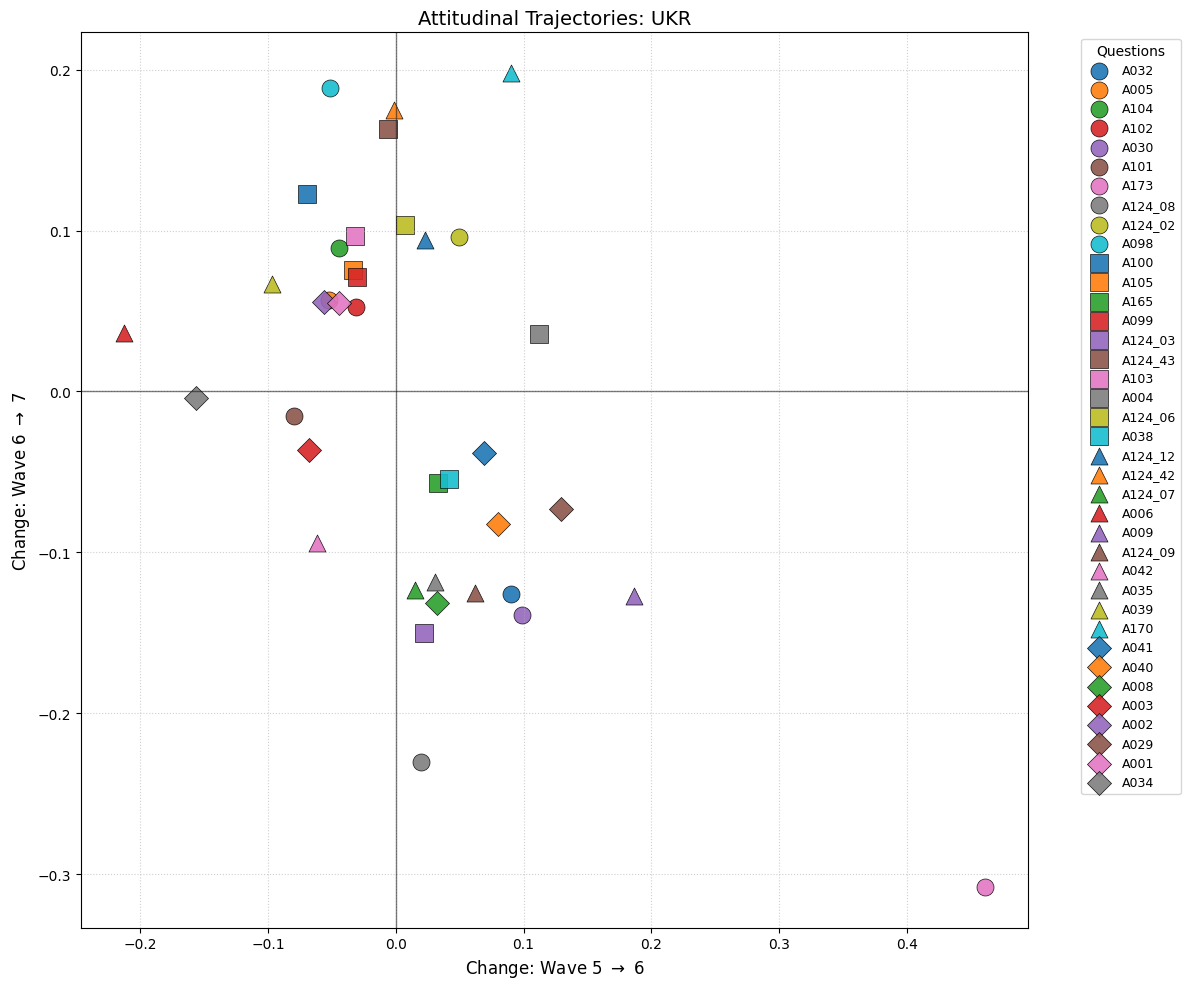

In [82]:
import pandas as pd
question_prefix = 'A'
wave_a = '5'
wave_b = '6'
wave_c = '7'
wave_a_to_b = pd.read_csv(f'{significant_changes_path}/ks/{question_prefix}_wave{wave_a}_to_wave{wave_b}.csv')
wave_b_to_c = pd.read_csv(f'{significant_changes_path}/ks/{question_prefix}_wave{wave_b}_to_wave{wave_c}.csv')

plot_real_trajectory(
    country='UKR', 
    wave_a_to_b=wave_a_to_b, 
    wave_b_to_c=wave_b_to_c, 
    wave_a=wave_a, 
    wave_b=wave_b, 
    wave_c=wave_c
)

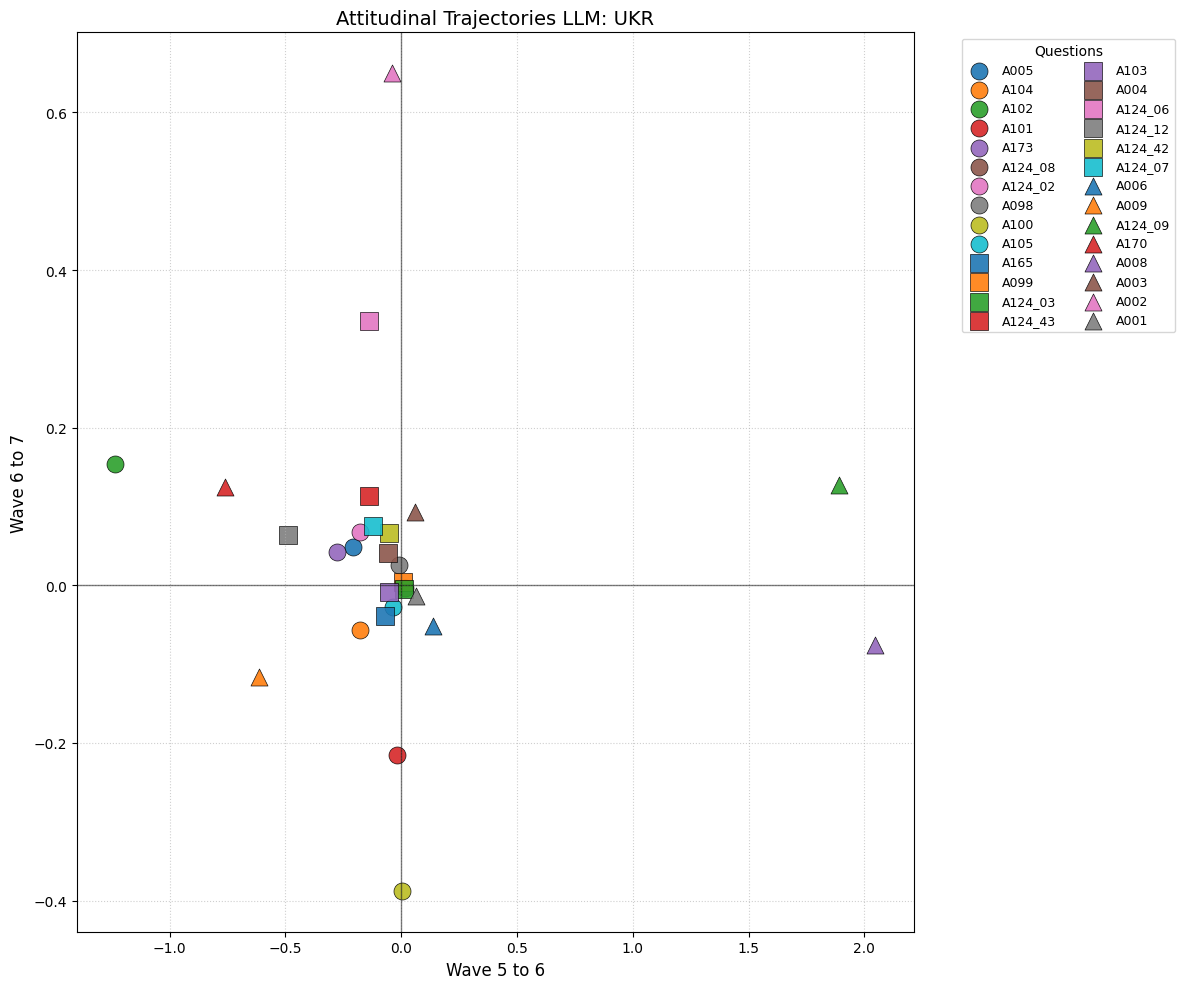

In [83]:
plot_llm_trajectory(deltas)

In [84]:
import matplotlib.pyplot as plt
import itertools

def plot_comparative_trajectories(country, wave_a_to_b, wave_b_to_c, wave_a, wave_b, wave_c, llm_deltas, exclude_prefixes=None):
    """
    Generates side-by-side attitudinal trajectory scatter plots (Real vs LLM) 
    for a specific country, ensuring perfectly matched styling for each question.
    """
    if exclude_prefixes is None:
        exclude_prefixes = ['E179']

    # --- 1. Identify all questions across both datasets ---
    # Real Data Questions
    q_a_b = set(wave_a_to_b[wave_a_to_b['country'] == country]['question'])
    q_b_c = set(wave_b_to_c[wave_b_to_c['country'] == country]['question'])
    real_questions = q_a_b.intersection(q_b_c)
    real_questions = {q for q in real_questions if not any(q.startswith(p) for p in exclude_prefixes)}

    # LLM Data Questions
    llm_questions = {k for k in llm_deltas.keys() if k != 'average'}

    # Combine and sort to guarantee consistent ordering across runs
    all_questions = sorted(list(real_questions.union(llm_questions)))

    # --- 2. Create a Universal Style Dictionary ---
    markers = ['o', 's', '^', 'D', 'p', '*', 'h', 'v', '<', '>']
    colors = plt.cm.tab10.colors  
    styles = list(itertools.product(markers, colors))

    # Hard-map each question to a specific (marker, color) combination
    style_map = {question: styles[i % len(styles)] for i, question in enumerate(all_questions)}

    # --- 3. Setup Side-by-Side Plot ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

    # --- 4. Plot Real Trajectory (ax1) ---
    for question in real_questions:
        marker_style, color_style = style_map[question]
        
        row_a_b = wave_a_to_b[(wave_a_to_b['country'] == country) & (wave_a_to_b['question'] == question)]
        delta_a_b = row_a_b['mean_wave_' + str(wave_b)].values[0] - row_a_b['mean_wave_' + str(wave_a)].values[0]
        
        row_b_c = wave_b_to_c[(wave_b_to_c['country'] == country) & (wave_b_to_c['question'] == question)]
        delta_b_c = row_b_c['mean_wave_' + str(wave_c)].values[0] - row_b_c['mean_wave_' + str(wave_b)].values[0]
        
        ax1.scatter(delta_a_b, delta_b_c, label=question, s=150, 
                    marker=marker_style, color=color_style,
                    alpha=0.9, edgecolor='black', linewidth=0.5)

    # --- 5. Plot LLM Trajectory (ax2) ---
    for question in llm_questions:
        marker_style, color_style = style_map[question]
        
        delta_1 = llm_deltas[question]['delta_1']
        delta_2 = llm_deltas[question]['delta_2']
        
        ax2.scatter(delta_1, delta_2, label=question, s=150, 
                    marker=marker_style, color=color_style,
                    alpha=0.9, edgecolor='black', linewidth=0.5)

    # --- 6. Formatting Both Axes ---
    # Using a loop to apply identical gridlines and axis rules to both plots
    for ax, title, x_lbl, y_lbl in zip(
        [ax1, ax2],
        [f'Real Trajectories: {country}', f'LLM Trajectories: {country}'],
        [f'Change: Wave {wave_a} $\\rightarrow$ {wave_b}', 'Change: Wave 5 $\\rightarrow$ 6 (LLM)'],
        [f'Change: Wave {wave_b} $\\rightarrow$ {wave_c}', 'Change: Wave 6 $\\rightarrow$ 7 (LLM)']
    ):
        ax.axhline(0, color='black', linewidth=1, alpha=0.5)
        ax.axvline(0, color='black', linewidth=1, alpha=0.5)
        ax.set_xlabel(x_lbl, fontsize=12)
        ax.set_ylabel(y_lbl, fontsize=12)
        ax.set_title(title, fontsize=14)
        ax.grid(True, linestyle=':', alpha=0.6)

    # --- 7. Unified Shared Legend ---
    # Gather handles from BOTH plots to ensure no question is left out
    handles, labels = [], []
    for ax in [ax1, ax2]:
        for handle, label in zip(*ax.get_legend_handles_labels()):
            if label not in labels:
                handles.append(handle)
                labels.append(label)

    # Place one master legend to the right of the entire figure
    fig.legend(handles, labels, title="Questions", 
               bbox_to_anchor=(1.01, 0.95), loc='upper left', 
               fontsize=10, ncol=2)

    plt.tight_layout()
    plt.show()

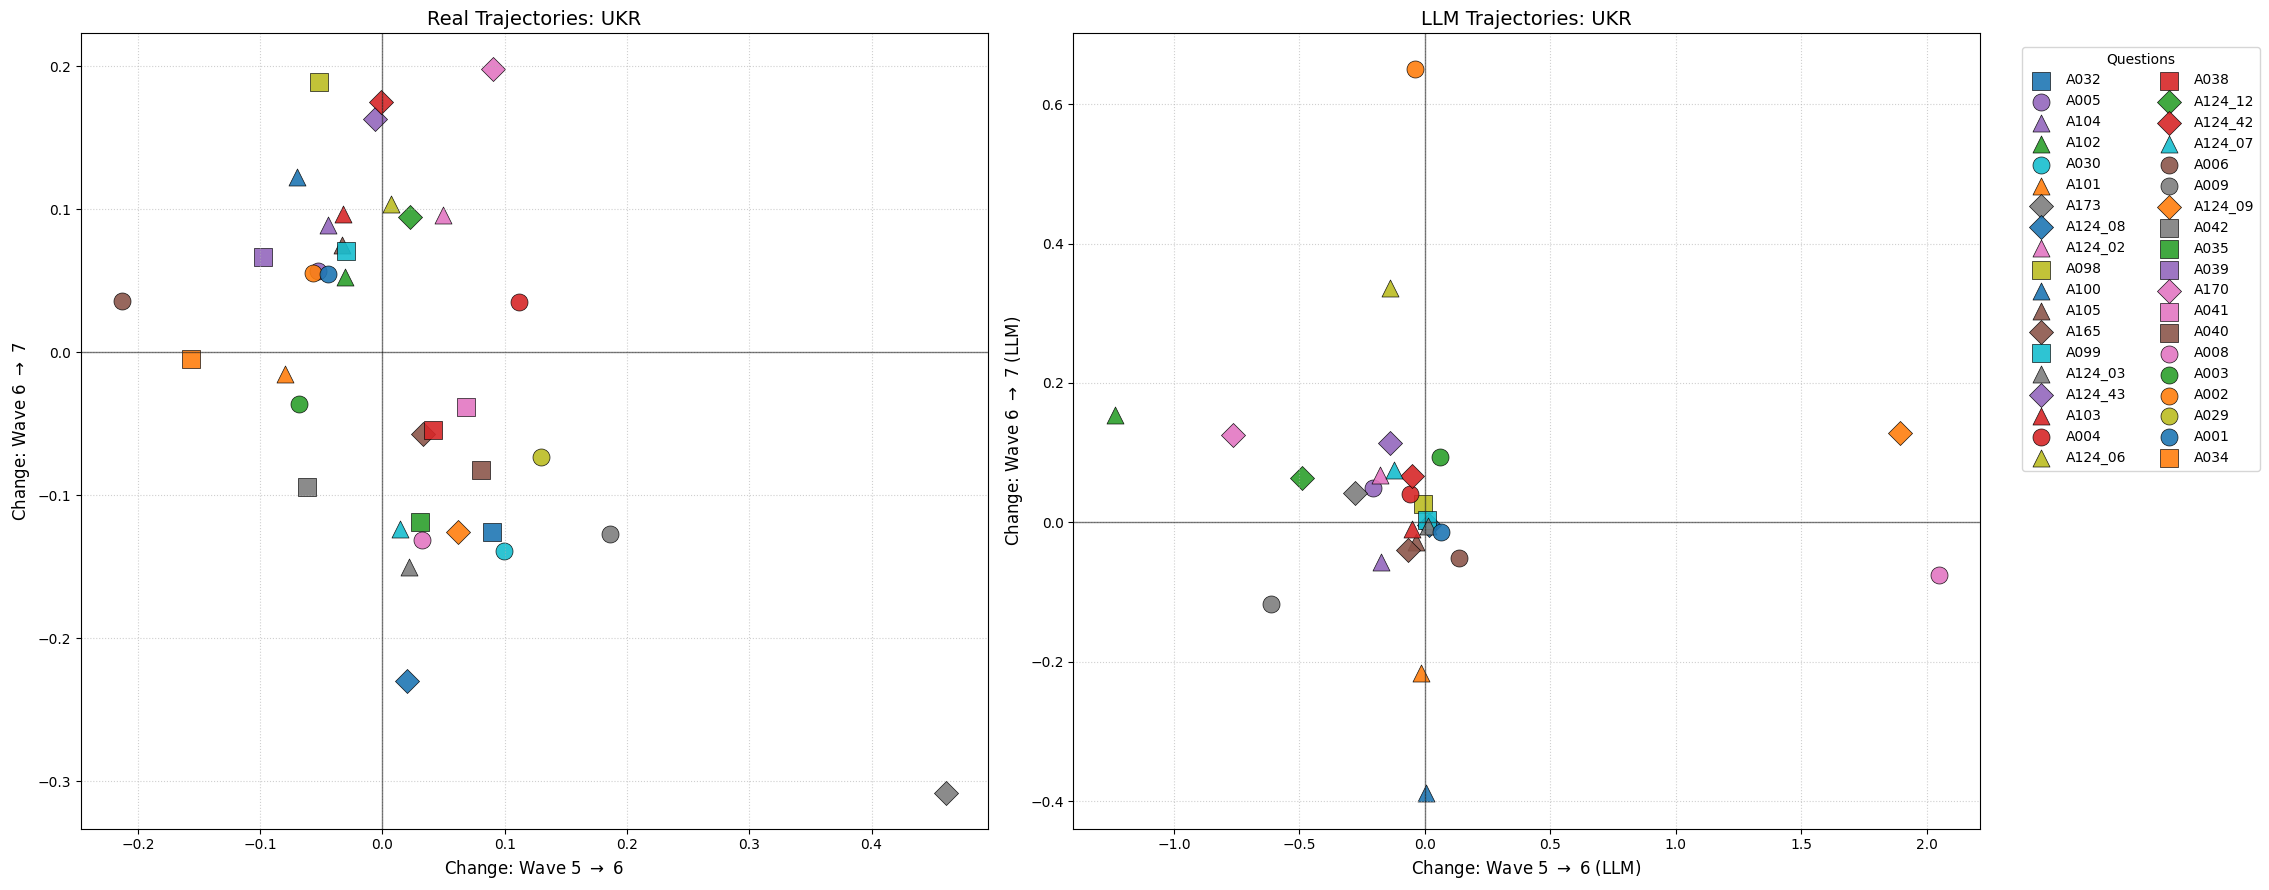

In [85]:

plot_comparative_trajectories(
    country='UKR',                 # The specific country code you want to plot
    wave_a_to_b=wave_a_to_b,       # The DataFrame containing the first real data delta
    wave_b_to_c=wave_b_to_c,       # The DataFrame containing the second real data delta
    wave_a=5,                      # The starting wave number
    wave_b=6,                      # The middle wave number
    wave_c=7,                      # The final wave number
    llm_deltas=deltas,   # Your dictionary containing the LLM deltas
    exclude_prefixes=['E179']      # (Optional) List of question prefixes to ignore
)